# 04 - Model Calibration, Threshold and Business Optimization

Notebook này chuyển kết quả dự đoán churn từ góc nhìn kỹ thuật sang một quyết định có thể sử dụng trong kinh doanh. Model classification không chỉ tạo nhãn `Churn/No Churn`, mà trước hết tạo **xác suất churn** cho từng khách hàng. Threshold quyết định mức xác suất nào đủ cao để khách hàng được đưa vào chiến dịch giữ chân.

Threshold mặc định `0.5` không nhất thiết phù hợp với mục tiêu kinh doanh. Threshold thấp giúp phát hiện nhiều khách churn hơn nhưng làm tăng số khách không churn bị cảnh báo nhầm. Threshold cao giúp danh sách chính xác hơn nhưng có thể bỏ sót nhiều khách hàng sắp rời bỏ.

### Mục tiêu của Phase 5

- Kiểm tra khả năng phân biệt và chất lượng xác suất của model tốt nhất.
- Phân tích ROC curve và Precision-Recall curve.
- Thử nhiều threshold từ `0.10` đến `0.90`.
- Đo Precision, Recall, F1-score và số khách hàng bị flag tại từng threshold.
- Mô phỏng chi phí/lợi ích của chiến dịch giữ chân.
- Chọn threshold ưu tiên Recall nhưng không để Precision quá thấp.
- Xây dựng danh sách khách hàng ưu tiên và đề xuất hành động retention.

### Lưu ý phương pháp

Các giả định chi phí trong notebook là kịch bản minh họa, không phải số liệu tài chính thực tế. Khi triển khai, doanh nghiệp cần thay thế bằng customer lifetime value, chi phí ưu đãi, tỷ lệ giữ chân và ngân sách thực tế. Threshold được chọn trên tập đánh giá hiện tại nên cần được xác nhận lại trên validation set độc lập hoặc dữ liệu theo thời gian trước khi đưa vào vận hành.

## 1. Import thư viện và đọc cấu hình

Phần này đọc lại cấu hình dự án, cấu hình classification và các giả định business. Việc lưu giả định trong YAML giúp kết quả minh bạch, dễ thay đổi và có thể tái lập mà không sửa trực tiếp logic notebook.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

with (PROJECT_ROOT / "configs" / "base.yaml").open("r", encoding="utf-8") as file:
    base_config = yaml.safe_load(file)

with (PROJECT_ROOT / "configs" / "classification.yaml").open("r", encoding="utf-8") as file:
    classification_config = yaml.safe_load(file)

REPORTS_DIR = PROJECT_ROOT / base_config["paths"]["reports_dir"]
MODELS_DIR = PROJECT_ROOT / base_config["paths"]["models_dir"]
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

threshold_config = classification_config["threshold_optimization"]
business_config = classification_config["business"]

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (9, 5)

print("Threshold constraints:", threshold_config)
print("Business assumptions:", business_config)

Threshold constraints: {'threshold_min': 0.1, 'threshold_max': 0.9, 'threshold_step': 0.05, 'minimum_precision': 0.4, 'minimum_recall': 0.7}
Business assumptions: {'intervention_cost_per_customer': 50, 'retained_customer_value': 600, 'retention_success_rate': 0.3, 'missed_churn_cost': 400}


## 2. Load model tốt nhất và tái tạo tập đánh giá

Phase 4 đã chọn Logistic Regression theo F1-score và Recall của lớp churn. Notebook này load toàn bộ pipeline đã lưu, gồm preprocessing và estimator, sau đó lấy lại đúng các khách hàng trong tập test thông qua `customerID`.

Việc gọi lại `predict_proba` từ model đã lưu giúp xác nhận artifact có thể sử dụng độc lập. Xác suất mới được đối chiếu với file prediction của Phase 4; sai khác phải gần bằng 0.

In [2]:
model_path = MODELS_DIR / "best_model.joblib"
metadata_path = MODELS_DIR / "best_model_metadata.json"
prediction_path = REPORTS_DIR / "classification_test_predictions.csv"

best_model = joblib.load(model_path)

with metadata_path.open("r", encoding="utf-8") as file:
    model_metadata = json.load(file)

saved_predictions = pd.read_csv(prediction_path)
features = pd.read_csv(PROJECT_ROOT / base_config["paths"]["features"])

id_column = base_config["dataset"]["id_column"]
feature_lookup = features.set_index(id_column)
X_eval = feature_lookup.loc[saved_predictions[id_column]].reset_index(drop=True)
y_eval = saved_predictions["actual_churn"].astype(int)

probability_column = model_metadata["best_model"].lower().replace(" ", "_") + "_probability"
y_probability = best_model.predict_proba(X_eval)[:, 1]
max_probability_difference = np.max(np.abs(y_probability - saved_predictions[probability_column]))

assert max_probability_difference < 1e-10, "Xác suất không khớp với Phase 4."

print("Best model:", model_metadata["best_model"])
print("Evaluation rows:", len(X_eval))
print("Actual churn customers:", int(y_eval.sum()))
print("Maximum probability difference:", max_probability_difference)

Best model: Logistic Regression
Evaluation rows: 1409
Actual churn customers: 374
Maximum probability difference: 1.1102230246251565e-16


### Kiểm tra phân phối xác suất

Histogram xác suất cho biết model phân tách hai lớp như thế nào. Một model tốt thường gán xác suất cao hơn cho phần lớn khách churn và thấp hơn cho phần lớn khách không churn, nhưng hai phân phối vẫn có vùng chồng lấn. Vùng chồng lấn chính là nơi threshold tạo ra trade-off giữa False Positive và False Negative.

,count,mean,std,min,25%,50%,75%,max
actual_churn,,,,,,,,
No,1035.0,0.32,0.272,0.006,0.078,0.243,0.542,0.920
Yes,374.0,0.68,0.211,0.017,0.551,0.751,0.847,0.938


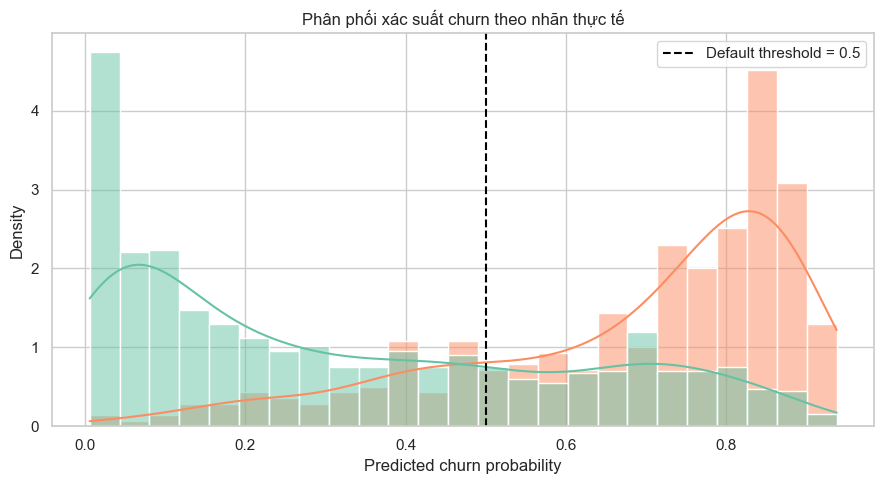

In [3]:
probability_df = pd.DataFrame({
    "actual_churn": y_eval.map({0: "No", 1: "Yes"}),
    "churn_probability": y_probability,
})

display(probability_df.groupby("actual_churn")["churn_probability"].describe().round(3))

sns.histplot(
    data=probability_df,
    x="churn_probability",
    hue="actual_churn",
    bins=25,
    stat="density",
    common_norm=False,
    kde=True,
)
plt.axvline(0.5, color="black", linestyle="--", label="Default threshold = 0.5")
plt.title("Phân phối xác suất churn theo nhãn thực tế")
plt.xlabel("Predicted churn probability")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "churn_probability_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Đánh giá khả năng phân biệt: ROC và Precision-Recall curve

Hai đường cong đánh giá model trên toàn bộ threshold:

- **ROC curve:** biểu diễn True Positive Rate theo False Positive Rate. ROC-AUC đo khả năng xếp một khách churn cao hơn một khách không churn.
- **Precision-Recall curve:** biểu diễn Precision theo Recall và phù hợp hơn khi lớp churn ít hơn lớp không churn. Average Precision tóm tắt chất lượng của đường cong này.

Một threshold thấp di chuyển theo hướng Recall cao nhưng Precision thường giảm. Không có một điểm tối ưu tuyệt đối nếu chưa biết chi phí của từng loại sai số.

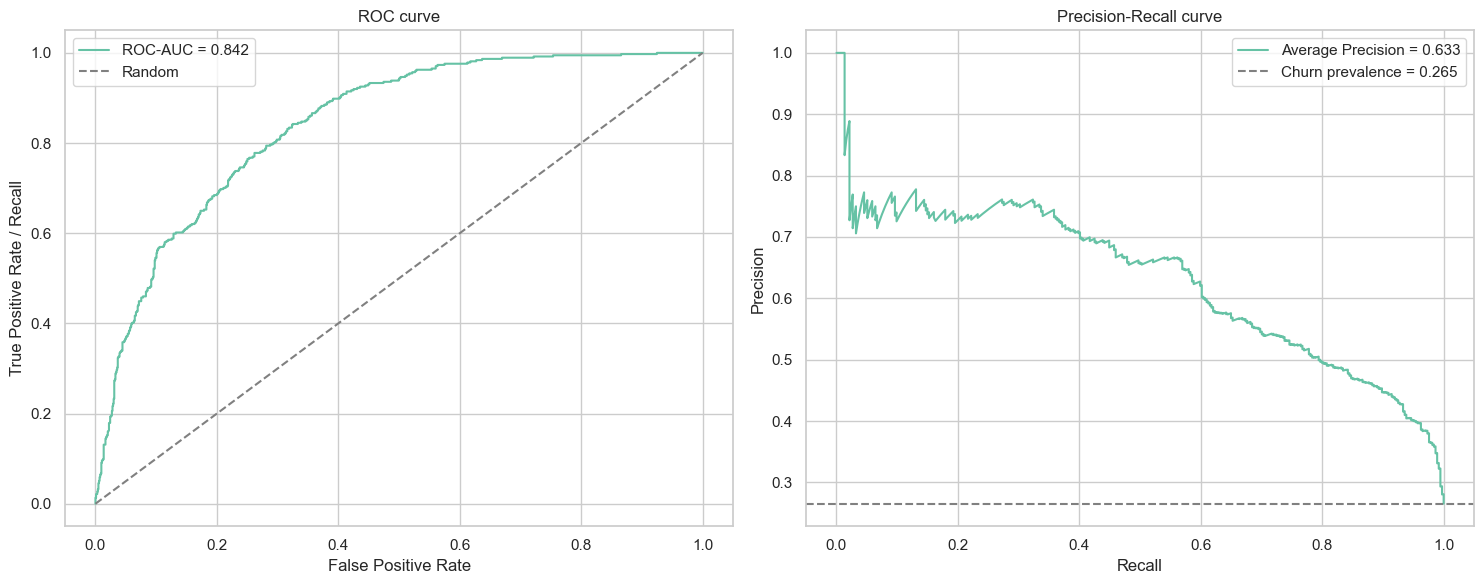

ROC-AUC: 0.842
Average Precision: 0.633


In [4]:
roc_auc = roc_auc_score(y_eval, y_probability)
average_precision = average_precision_score(y_eval, y_probability)
fpr, tpr, roc_thresholds = roc_curve(y_eval, y_probability)
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_eval, y_probability)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[0].set_title("ROC curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate / Recall")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, label=f"Average Precision = {average_precision:.3f}")
axes[1].axhline(y_eval.mean(), linestyle="--", color="gray", label=f"Churn prevalence = {y_eval.mean():.3f}")
axes[1].set_title("Precision-Recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / "roc_precision_recall_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Average Precision: {average_precision:.3f}")

## 4. Kiểm tra calibration của xác suất

**Discrimination** và **calibration** là hai khái niệm khác nhau. Model có thể xếp hạng đúng khách rủi ro cao nhưng xác suất dự báo chưa phản ánh đúng tần suất thực tế.

Ví dụ, nếu nhóm khách được dự báo khoảng 0.70 chỉ có 50% thực sự churn, model đang overestimate risk. Calibration curve so sánh xác suất trung bình với tỷ lệ churn quan sát trong từng bin. Đường chéo là calibration hoàn hảo.

Brier score là trung bình bình phương sai số giữa xác suất và nhãn 0/1; giá trị càng thấp càng tốt. Do model sử dụng `class_weight='balanced'`, xác suất có thể bị dịch chuyển để ưu tiên Recall. Vì vậy, xác suất nên được hiểu chủ yếu như risk score cho đến khi được calibration bằng validation data độc lập.

,mean_predicted_probability,observed_churn_rate,calibration_gap
0,0.016,0.014,0.002
1,0.055,0.007,0.048
2,0.116,0.043,0.073
3,0.209,0.106,0.103
4,0.333,0.170,0.163
5,0.456,0.250,0.206
6,0.593,0.340,0.252
7,0.710,0.404,0.306
8,0.797,0.560,0.237
9,0.874,0.759,0.115


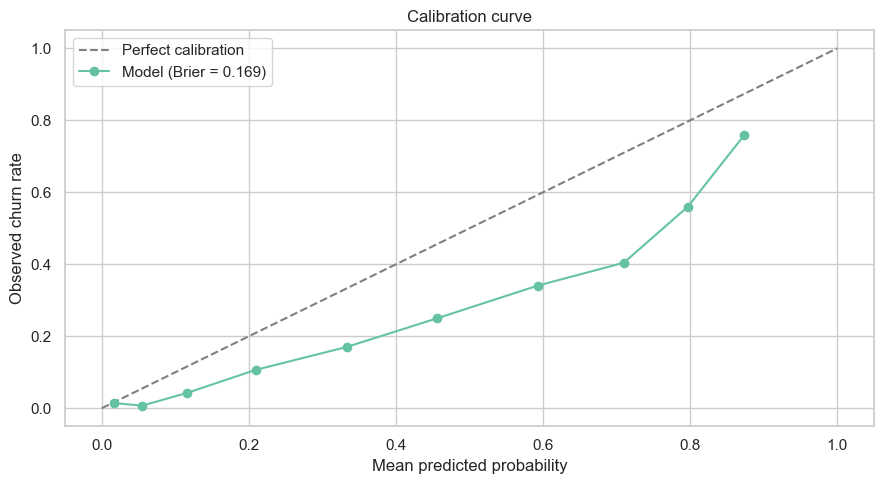

Brier score: 0.169


In [5]:
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_eval,
    y_probability,
    n_bins=10,
    strategy="quantile",
)
brier_score = brier_score_loss(y_eval, y_probability)

calibration_table = pd.DataFrame({
    "mean_predicted_probability": mean_predicted_value,
    "observed_churn_rate": fraction_of_positives,
})
calibration_table["calibration_gap"] = (
    calibration_table["mean_predicted_probability"] - calibration_table["observed_churn_rate"]
)
display(calibration_table.round(3))

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.plot(mean_predicted_value, fraction_of_positives, marker="o", label=f"Model (Brier = {brier_score:.3f})")
plt.title("Calibration curve")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed churn rate")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "model_calibration_curve.png", dpi=150, bbox_inches="tight")
plt.show()

calibration_table.to_csv(REPORTS_DIR / "model_calibration_table.csv", index=False)
print(f"Brier score: {brier_score:.3f}")

### Kết quả calibration thực tế

Model đạt **Brier score khoảng 0.169**. Calibration table cho thấy xác suất dự báo cao hơn tỷ lệ churn quan sát ở phần lớn các bin. Ví dụ, một nhóm có xác suất trung bình khoảng 0.71 chỉ ghi nhận churn rate khoảng 0.40; nhóm có xác suất trung bình khoảng 0.80 ghi nhận churn rate khoảng 0.56.

Điều này cho thấy model có xu hướng **overestimate xác suất churn**, đặc biệt ở vùng rủi ro trung bình và cao. Nguyên nhân hợp lý là Logistic Regression được huấn luyện với `class_weight='balanced'`, khiến model tăng mức chú ý đến lớp churn để đạt Recall cao hơn. Vì vậy:

- Xác suất hiện tại vẫn hữu ích để xếp hạng khách hàng theo rủi ro.
- Không nên diễn giải trực tiếp `0.70` là khách hàng có chính xác 70% khả năng churn.
- Nếu xác suất tuyệt đối được dùng cho pricing, dự báo doanh thu hoặc phân bổ ngân sách, cần calibration bằng `CalibratedClassifierCV` trên validation set độc lập.
- Việc calibration có thể thay đổi threshold số học nhưng không nhất thiết thay đổi nhiều thứ tự xếp hạng khách hàng.

## 5. Phân tích nhiều threshold

Threshold được thử từ `0.10` đến `0.90`, bước nhảy `0.05`. Tại mỗi threshold, notebook tính:

- `precision`: độ chính xác trong nhóm bị flag.
- `recall`: tỷ lệ khách churn được phát hiện.
- `f1`: mức cân bằng giữa Precision và Recall.
- `flagged_customers`: số khách cần được đưa vào chiến dịch.
- `flag_rate`: tỷ lệ tập khách hàng bị flag, đại diện cho quy mô chiến dịch.
- `TP`, `FP`, `FN`, `TN`: thành phần confusion matrix.

Bảng này cho phép doanh nghiệp nhìn thấy chi phí vận hành của việc tăng Recall. Recall không thể tăng miễn phí: threshold càng thấp thì danh sách khách hàng cần xử lý càng lớn.

In [6]:
thresholds = np.round(np.arange(
    threshold_config["threshold_min"],
    threshold_config["threshold_max"] + threshold_config["threshold_step"] / 2,
    threshold_config["threshold_step"],
), 2)

threshold_rows = []

for threshold in thresholds:
    y_pred = (y_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred, labels=[0, 1]).ravel()

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "flagged_customers": int(y_pred.sum()),
        "flag_rate": y_pred.mean(),
        "true_positive": int(tp),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_negative": int(tn),
    })

threshold_metrics = pd.DataFrame(threshold_rows)
display(threshold_metrics.style.format({
    "threshold": "{:.2f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "flag_rate": "{:.1%}",
}))

threshold_metrics.to_csv(REPORTS_DIR / "threshold_metrics.csv", index=False)

,threshold,precision,recall,f1,flagged_customers,flag_rate,true_positive,false_positive,false_negative,true_negative
0,0.10,0.342,0.989,0.508,1083,76.9%,370,713,4,322
1,0.15,0.367,0.976,0.534,994,70.5%,365,629,9,406
2,0.20,0.388,0.963,0.553,927,65.8%,360,567,14,468
3,0.25,0.407,0.939,0.568,863,61.2%,351,512,23,523
4,0.30,0.429,0.928,0.587,808,57.3%,347,461,27,574
5,0.35,0.447,0.904,0.598,756,53.7%,338,418,36,617
6,0.40,0.467,0.866,0.607,694,49.3%,324,370,50,665
7,0.45,0.483,0.840,0.613,650,46.1%,314,336,60,699
8,0.50,0.504,0.783,0.614,581,41.2%,293,288,81,747
9,0.55,0.525,0.751,0.618,535,38.0%,281,254,93,781


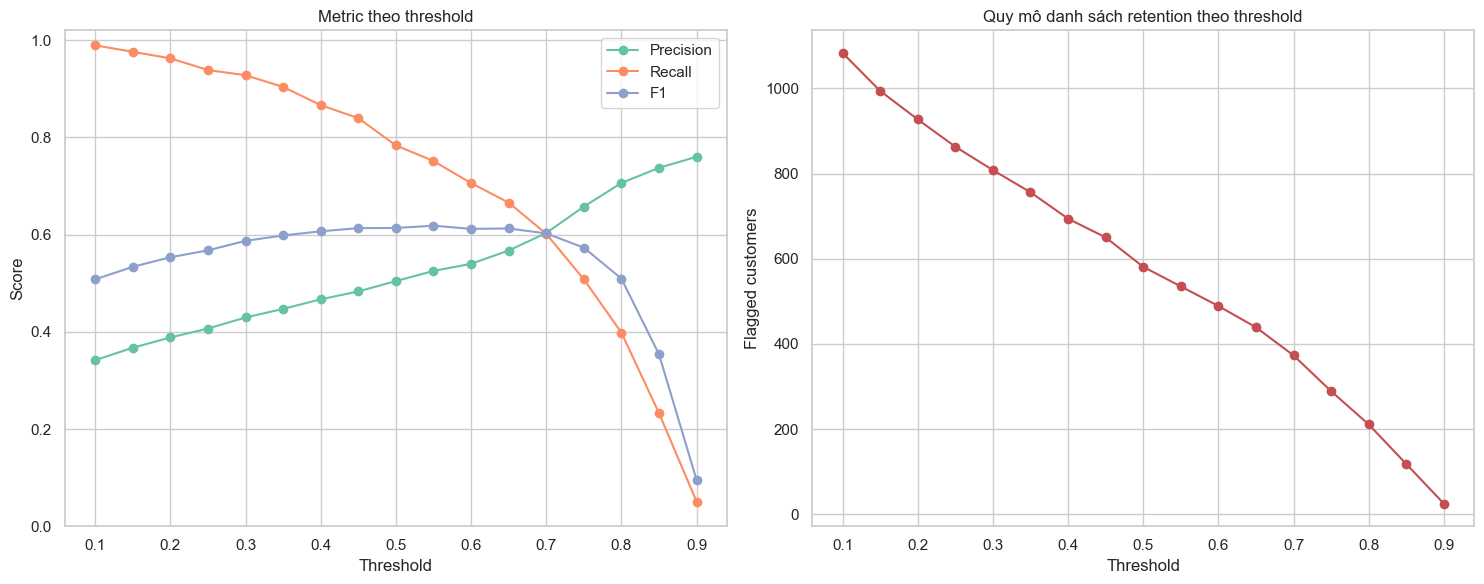

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(threshold_metrics["threshold"], threshold_metrics["precision"], marker="o", label="Precision")
axes[0].plot(threshold_metrics["threshold"], threshold_metrics["recall"], marker="o", label="Recall")
axes[0].plot(threshold_metrics["threshold"], threshold_metrics["f1"], marker="o", label="F1")
axes[0].set_title("Metric theo threshold")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.02)
axes[0].legend()

axes[1].plot(threshold_metrics["threshold"], threshold_metrics["flagged_customers"], marker="o", color="#c44e52")
axes[1].set_title("Quy mô danh sách retention theo threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Flagged customers")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "threshold_metric_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Business optimization

Một threshold chỉ có ý nghĩa khi được liên kết với chi phí và lợi ích. Notebook sử dụng kịch bản minh họa sau:

- Mỗi khách hàng bị flag phát sinh chi phí liên hệ/ưu đãi.
- Chỉ một tỷ lệ khách churn được can thiệp thành công.
- Mỗi khách giữ lại thành công tạo ra một giá trị kỳ vọng.
- Khách churn bị bỏ sót tạo ra chi phí mất khách.

Công thức mô phỏng:

`Expected net value = expected retained value - intervention cost - missed churn cost`

Trong đó:

- `expected retained customers = TP × retention success rate`
- `expected retained value = expected retained customers × retained customer value`
- `intervention cost = (TP + FP) × intervention cost per customer`
- `missed churn cost = FN × missed churn cost`

Đây là một decision model đơn giản. Nó chưa tính sự khác nhau về Customer Lifetime Value, mức ưu đãi theo phân khúc, khả năng khách tự ở lại hoặc tác động dài hạn của chiến dịch.

In [8]:
intervention_cost = business_config["intervention_cost_per_customer"]
retained_value = business_config["retained_customer_value"]
retention_success_rate = business_config["retention_success_rate"]
missed_churn_cost = business_config["missed_churn_cost"]

business_analysis = threshold_metrics.copy()
business_analysis["expected_retained_customers"] = (
    business_analysis["true_positive"] * retention_success_rate
)
business_analysis["expected_retained_value"] = (
    business_analysis["expected_retained_customers"] * retained_value
)
business_analysis["intervention_cost"] = (
    business_analysis["flagged_customers"] * intervention_cost
)
business_analysis["missed_churn_cost"] = (
    business_analysis["false_negative"] * missed_churn_cost
)
business_analysis["expected_net_value"] = (
    business_analysis["expected_retained_value"]
    - business_analysis["intervention_cost"]
    - business_analysis["missed_churn_cost"]
)

display(business_analysis.style.format({
    "threshold": "{:.2f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "flag_rate": "{:.1%}",
    "expected_retained_customers": "{:.1f}",
    "expected_retained_value": "{:,.0f}",
    "intervention_cost": "{:,.0f}",
    "missed_churn_cost": "{:,.0f}",
    "expected_net_value": "{:,.0f}",
}))

business_analysis.to_csv(REPORTS_DIR / "business_threshold_analysis.csv", index=False)

,threshold,precision,recall,f1,flagged_customers,flag_rate,true_positive,false_positive,false_negative,true_negative,expected_retained_customers,expected_retained_value,intervention_cost,missed_churn_cost,expected_net_value
0,0.10,0.342,0.989,0.508,1083,76.9%,370,713,4,322,111.0,"66,600","54,150","1,600","10,850"
1,0.15,0.367,0.976,0.534,994,70.5%,365,629,9,406,109.5,"65,700","49,700","3,600","12,400"
2,0.20,0.388,0.963,0.553,927,65.8%,360,567,14,468,108.0,"64,800","46,350","5,600","12,850"
3,0.25,0.407,0.939,0.568,863,61.2%,351,512,23,523,105.3,"63,180","43,150","9,200","10,830"
4,0.30,0.429,0.928,0.587,808,57.3%,347,461,27,574,104.1,"62,460","40,400","10,800","11,260"
5,0.35,0.447,0.904,0.598,756,53.7%,338,418,36,617,101.4,"60,840","37,800","14,400","8,640"
6,0.40,0.467,0.866,0.607,694,49.3%,324,370,50,665,97.2,"58,320","34,700","20,000","3,620"
7,0.45,0.483,0.840,0.613,650,46.1%,314,336,60,699,94.2,"56,520","32,500","24,000",20
8,0.50,0.504,0.783,0.614,581,41.2%,293,288,81,747,87.9,"52,740","29,050","32,400","-8,710"
9,0.55,0.525,0.751,0.618,535,38.0%,281,254,93,781,84.3,"50,580","26,750","37,200","-13,370"


## 7. Chọn threshold đề xuất

Mục tiêu được xác định trước là ưu tiên Recall nhưng không để Precision quá thấp. Notebook áp dụng hai ràng buộc từ config:

- `Recall >= 0.70`: phát hiện ít nhất 70% khách churn.
- `Precision >= 0.40`: ít nhất 40% khách bị flag thực sự churn.

Trong các threshold thỏa cả hai điều kiện, chọn threshold có `expected_net_value` cao nhất; nếu bằng nhau, ưu tiên F1 và Recall. Cách chọn này kết hợp yêu cầu vận hành với business simulation thay vì tối ưu một metric kỹ thuật đơn lẻ.

Các ràng buộc 0.70 và 0.40 chỉ là policy minh họa. Doanh nghiệp có thể điều chỉnh dựa trên năng lực contact center, ngân sách ưu đãi và mức độ chấp nhận False Positive.

In [9]:
eligible_thresholds = business_analysis.loc[
    (business_analysis["precision"] >= threshold_config["minimum_precision"])
    & (business_analysis["recall"] >= threshold_config["minimum_recall"])
].copy()

if eligible_thresholds.empty:
    selected_row = business_analysis.sort_values(
        ["f1", "recall", "expected_net_value"], ascending=False
    ).iloc[0]
    selection_note = "Không có threshold thỏa cả hai ràng buộc; chọn F1 cao nhất."
else:
    selected_row = eligible_thresholds.sort_values(
        ["expected_net_value", "f1", "recall"], ascending=False
    ).iloc[0]
    selection_note = "Chọn expected net value cao nhất trong nhóm thỏa Precision/Recall tối thiểu."

selected_threshold = float(selected_row["threshold"])
default_row = business_analysis.loc[np.isclose(business_analysis["threshold"], 0.5)].iloc[0]

comparison = pd.DataFrame([
    {"scenario": "Default threshold", **default_row.to_dict()},
    {"scenario": "Selected threshold", **selected_row.to_dict()},
])

display(comparison[[
    "scenario", "threshold", "precision", "recall", "f1",
    "flagged_customers", "true_positive", "false_positive",
    "false_negative", "expected_net_value"
]].style.format({
    "threshold": "{:.2f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "expected_net_value": "{:,.0f}",
}))

print("Selected threshold:", selected_threshold)
print(selection_note)

,scenario,threshold,precision,recall,f1,flagged_customers,true_positive,false_positive,false_negative,expected_net_value
0,Default threshold,0.50,0.504,0.783,0.614,581.000000,293.000000,288.000000,81.000000,"-8,710"
1,Selected threshold,0.30,0.429,0.928,0.587,808.000000,347.000000,461.000000,27.000000,"11,260"


Selected threshold: 0.3
Chọn expected net value cao nhất trong nhóm thỏa Precision/Recall tối thiểu.


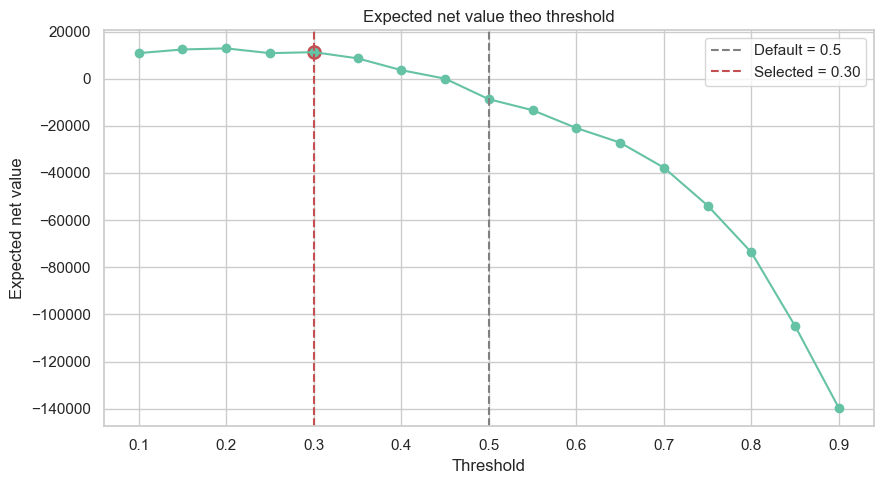

In [10]:
plt.plot(business_analysis["threshold"], business_analysis["expected_net_value"], marker="o")
plt.axvline(0.5, color="gray", linestyle="--", label="Default = 0.5")
plt.axvline(selected_threshold, color="#c44e52", linestyle="--", label=f"Selected = {selected_threshold:.2f}")
plt.scatter([selected_threshold], [selected_row["expected_net_value"]], color="#c44e52", s=90)
plt.title("Expected net value theo threshold")
plt.xlabel("Threshold")
plt.ylabel("Expected net value")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "business_value_by_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

### Kết quả lựa chọn threshold

Theo các ràng buộc đã đặt ra, threshold đề xuất là **0.30**. Tại điểm này:

- **Precision:** khoảng **42.95%**.
- **Recall:** khoảng **92.78%**.
- **F1-score:** khoảng **58.71%**.
- **Khách hàng bị flag:** **808/1,409**, tương đương khoảng 57.3% tập đánh giá.
- **True Positive:** 347 khách churn được phát hiện.
- **False Negative:** 27 khách churn bị bỏ sót.
- **False Positive:** 461 khách không churn bị đưa vào danh sách.
- **Expected net value trong kịch bản:** 11,260 đơn vị giá trị.

So với threshold mặc định 0.50, threshold 0.30 tăng đáng kể Recall từ khoảng 78.34% lên 92.78% và giảm số khách churn bị bỏ sót từ 81 xuống 27. Đổi lại, danh sách retention tăng từ 581 lên 808 khách và Precision giảm từ khoảng 50.43% xuống 42.95%.

Đây là lựa chọn phù hợp khi doanh nghiệp đánh giá chi phí bỏ sót churn cao hơn chi phí tiếp cận nhầm. Tuy nhiên, 808 khách trên 1,409 là quy mô chiến dịch lớn. Nếu contact center không đủ năng lực, có thể dùng risk tier để xử lý nhóm Critical trước hoặc tăng threshold lên 0.35-0.45 để thu hẹp danh sách.

Threshold 0.20 có expected net value cao hơn trong mô phỏng tổng thể, nhưng Precision khoảng 38.84% không đạt policy tối thiểu 40%. Việc không chọn 0.20 minh họa rằng business optimization phải đồng thời tuân thủ giới hạn chất lượng và năng lực vận hành, không chỉ tối đa hóa một con số.

## 8. Xây dựng danh sách khách hàng ưu tiên giữ chân

Khách hàng có xác suất churn từ threshold đề xuất trở lên được đưa vào danh sách retention. Danh sách được sắp xếp theo xác suất giảm dần để doanh nghiệp có thể ưu tiên khi ngân sách hoặc năng lực liên hệ bị giới hạn.

Ngoài xác suất, danh sách giữ lại các feature có ý nghĩa hành động như tenure, Contract, InternetService, MonthlyCharges, OnlineSecurity, TechSupport và PaymentMethod. Các thông tin này giúp retention team hiểu bối cảnh và chọn thông điệp phù hợp, thay vì chỉ nhận một risk score.

Risk tier được tạo tương đối quanh threshold:

- **Critical:** xác suất cao hơn threshold ít nhất 0.20.
- **High:** xác suất từ threshold đề xuất đến dưới mức Critical.
- **Watchlist:** thấp hơn threshold nhưng nằm trong khoảng theo dõi gần.
- **Low:** phần còn lại.

Trong vận hành thực tế, `actual_churn` không tồn tại tại thời điểm dự đoán. Cột này chỉ được giữ trong báo cáo đánh giá lịch sử, không nên đưa cho hệ thống scoring production.

In [11]:
critical_cutoff = min(selected_threshold + 0.20, 0.95)
watchlist_cutoff = max(selected_threshold - 0.15, 0.0)

priority_customers = X_eval.copy()
priority_customers.insert(0, id_column, saved_predictions[id_column].values)
priority_customers["actual_churn"] = y_eval.values
priority_customers["churn_probability"] = y_probability
priority_customers["selected_for_retention"] = y_probability >= selected_threshold
priority_customers["risk_tier"] = np.select(
    [
        y_probability >= critical_cutoff,
        y_probability >= selected_threshold,
        y_probability >= watchlist_cutoff,
    ],
    ["Critical", "High", "Watchlist"],
    default="Low",
)

priority_columns = [
    id_column, "churn_probability", "risk_tier", "selected_for_retention",
    "tenure", "Contract", "InternetService", "MonthlyCharges",
    "OnlineSecurity", "TechSupport", "PaymentMethod", "actual_churn",
]

retention_priority = (
    priority_customers.loc[priority_customers["selected_for_retention"], priority_columns]
    .sort_values("churn_probability", ascending=False)
    .reset_index(drop=True)
)

display(retention_priority.head(20))
display(priority_customers["risk_tier"].value_counts().to_frame("customers"))

retention_priority.to_csv(REPORTS_DIR / "retention_priority_customers.csv", index=False)

,customerID,churn_probability,risk_tier,selected_for_retention,tenure,Contract,InternetService,MonthlyCharges,OnlineSecurity,TechSupport,PaymentMethod,actual_churn
0,5178-LMXOP,0.937978,Critical,True,1,Month-to-month,Fiber optic,95.10,No,No,Electronic check,1
1,0295-PPHDO,0.926779,Critical,True,1,Month-to-month,Fiber optic,95.45,No,No,Electronic check,1
2,6861-XWTWQ,0.925977,Critical,True,7,Month-to-month,Fiber optic,99.25,No,No,Electronic check,1
3,8884-ADFVN,0.922239,Critical,True,7,Month-to-month,Fiber optic,101.95,No,No,Electronic check,1
4,1069-XAIEM,0.920495,Critical,True,1,Month-to-month,Fiber optic,85.05,No,No,Electronic check,1
5,2545-EBUPK,0.920278,Critical,True,2,Month-to-month,Fiber optic,84.05,No,No,Electronic check,0
6,1400-MMYXY,0.920128,Critical,True,3,Month-to-month,Fiber optic,105.90,No,No,Electronic check,1
7,6023-YEBUP,0.919386,Critical,True,3,Month-to-month,Fiber optic,100.95,No,No,Electronic check,1
8,9057-SIHCH,0.919010,Critical,True,3,Month-to-month,Fiber optic,96.60,No,No,Electronic check,1
9,8161-QYMTT,0.918038,Critical,True,7,Month-to-month,Fiber optic,94.10,No,No,Electronic check,0


,customers
risk_tier,
Critical,581
Low,415
High,227
Watchlist,186


## 9. Đề xuất hành động kinh doanh

### 9.1. Nhóm Critical

Liên hệ sớm qua kênh trực tiếp, ưu tiên xử lý nguyên nhân churn và đưa ra offer có điều kiện. Không nên chỉ giảm giá đại trà; cần phân biệt vấn đề chất lượng dịch vụ, giá, hỗ trợ kỹ thuật hay nhu cầu thay đổi gói.

### 9.2. Khách hàng mới và hợp đồng Month-to-month

Thiết kế chương trình onboarding trong 3-6 tháng đầu, kiểm tra mức độ hài lòng và đề xuất chuyển sang hợp đồng dài hạn bằng ưu đãi phù hợp. Có thể thử nghiệm miễn phí dịch vụ hỗ trợ hoặc ưu đãi cam kết một năm.

### 9.3. Fiber optic và MonthlyCharges cao

Rà soát chất lượng mạng, ticket hỗ trợ, độ ổn định và mức độ phù hợp của gói cước. Nếu khách hàng đang trả cao nhưng ít sử dụng, nên đề xuất gói phù hợp hơn thay vì chỉ khuyến mại ngắn hạn.

### 9.4. Thiếu OnlineSecurity hoặc TechSupport

Thử nghiệm bundle hoặc giai đoạn dùng thử để tăng giá trị cảm nhận và mức gắn kết. Hiệu quả cần được đo bằng nhóm đối chứng để tránh nhầm lẫn giữa correlation và tác động thực sự.

### 9.5. Electronic check

Khuyến khích chuyển sang auto-payment bằng trải nghiệm đăng ký đơn giản hoặc ưu đãi nhỏ. Tuy nhiên, PaymentMethod có thể chỉ là tín hiệu đại diện cho nhóm hợp đồng tháng, nên không nên coi đây là nguyên nhân duy nhất.

### 9.6. Đo lường chiến dịch

Theo dõi contact rate, offer acceptance, retention uplift, incremental revenue và cost per retained customer. Nên chạy A/B test hoặc randomized holdout để đo hiệu quả thật của can thiệp, thay vì so sánh trực tiếp nhóm được liên hệ với nhóm không được liên hệ.

## 10. Summary

Quá trình này cho thấy lựa chọn threshold là một bài toán quyết định, không chỉ là thao tác kỹ thuật. Threshold thấp tăng khả năng bắt được churn nhưng mở rộng chi phí chiến dịch; threshold cao giảm False Positive nhưng làm tăng số khách churn bị bỏ sót.

Threshold đề xuất được chọn bằng cách kết hợp ràng buộc Precision/Recall với expected net value trong kịch bản business. Kết quả cần được hiểu trong phạm vi giả định hiện tại và phải được kiểm tra độ nhạy khi chi phí, customer value hoặc retention success rate thay đổi.

Calibration diagnostics cho biết xác suất raw của model có thể chưa đại diện chính xác cho xác suất churn tuyệt đối, đặc biệt do sử dụng class weighting. Trong giai đoạn production, nên calibration model trên validation set độc lập và theo dõi calibration drift theo thời gian.

Danh sách retention priority biến model score thành đầu ra có thể hành động: ai cần được liên hệ trước, họ thuộc nhóm rủi ro nào và đặc điểm dịch vụ nào cần được xem xét.

In [12]:
selected_threshold_summary = {
    "model": model_metadata["best_model"],
    "selected_threshold": selected_threshold,
    "selection_note": selection_note,
    "minimum_precision": threshold_config["minimum_precision"],
    "minimum_recall": threshold_config["minimum_recall"],
    "roc_auc": float(roc_auc),
    "average_precision": float(average_precision),
    "brier_score": float(brier_score),
    "selected_metrics": {
        key: float(selected_row[key])
        for key in [
            "precision", "recall", "f1", "flagged_customers",
            "true_positive", "false_positive", "false_negative",
            "expected_retained_customers", "expected_net_value",
        ]
    },
    "business_assumptions": business_config,
}

with (MODELS_DIR / "selected_threshold.json").open("w", encoding="utf-8") as file:
    json.dump(selected_threshold_summary, file, indent=2, ensure_ascii=False)

print(json.dumps(selected_threshold_summary, indent=2, ensure_ascii=False))

{
  "model": "Logistic Regression",
  "selected_threshold": 0.3,
  "selection_note": "Chọn expected net value cao nhất trong nhóm thỏa Precision/Recall tối thiểu.",
  "minimum_precision": 0.4,
  "minimum_recall": 0.7,
  "roc_auc": 0.841501976284585,
  "average_precision": 0.6325016828753636,
  "brier_score": 0.16872361251229123,
  "selected_metrics": {
    "precision": 0.42945544554455445,
    "recall": 0.9278074866310161,
    "f1": 0.5871404399323181,
    "flagged_customers": 808.0,
    "true_positive": 347.0,
    "false_positive": 461.0,
    "false_negative": 27.0,
    "expected_retained_customers": 104.1,
    "expected_net_value": 11260.0
  },
  "business_assumptions": {
    "intervention_cost_per_customer": 50,
    "retained_customer_value": 600,
    "retention_success_rate": 0.3,
    "missed_churn_cost": 400
  }
}


## 11. Giới hạn và hướng mở rộng

- Model và threshold được đánh giá trên cùng holdout đã dùng để so sánh model ở Phase 4, nên kết quả có thể lạc quan. Quy trình tốt hơn là train/validation/test hoặc nested cross-validation.
- Business assumptions chưa dựa trên dữ liệu tài chính thực tế và chưa phân biệt giá trị từng khách hàng.
- Retention success rate được giả định cố định, trong khi thực tế phụ thuộc offer, kênh liên hệ và phân khúc.
- Calibration curve được đánh giá trên một tập hữu hạn; cần calibration và monitoring trên dữ liệu mới.
- Dataset không chứa lịch sử sử dụng, khiếu nại, chất lượng mạng hoặc phản hồi chiến dịch.
- Mô hình dự đoán khả năng churn, không dự đoán khách hàng nào có thể được thuyết phục ở lại. Bước nâng cao là **uplift modeling** để ước lượng tác động của can thiệp.

Các hướng mở rộng gồm cross-validation, hyperparameter tuning, probability calibration, customer-level CLV, sensitivity analysis, budget-constrained optimization và A/B testing.